Module 2: 构建算子——从单元素到空间

> 卷积用滑动窗口捕获局部纹理，注意力让每个 token 看到所有其他 token，LSTM 用门控对抗梯度消失——从代码层面理解每一个算子的数学本质。

## 0. 环境准备

导入所有需要的库。torch 做张量运算，numpy 辅助数据处理，matplotlib 可视化。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (12, 5)
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
print("Ready!")

PyTorch: 2.6.0+cu118
NumPy: 1.26.4
Ready!


---
## 1. 卷积——计算机视觉的放大镜

### 1.1 六个核心参数

卷积用两个先验知识替代全连接：**局部性**（一个像素只和周围像素有关）和**平移等变性**（特征在哪里都该被同样识别）。

H' = floor((H + 2*pad - dilation*(k-1) - 1) / stride + 1)

下面用代码验证每个参数的效果。

In [2]:
torch.manual_seed(42)
B, C_in, H, W = 1, 3, 8, 8
x = torch.randn(B, C_in, H, W)

print("=" * 55)
print("卷积六个参数效果演示")
print("=" * 55)

conv_k3 = nn.Conv2d(3, 16, 3, stride=1, padding=1)
conv_k5 = nn.Conv2d(3, 16, 5, stride=1, padding=2)
print(f"kernel=3, pad=1 -> {tuple(conv_k3(x).shape)} (same)")
print(f"kernel=5, pad=2 -> {tuple(conv_k5(x).shape)} (same, 感受野更大)")
print(f"  两个3x3 = 一个5x5感受野, 但参数 2*9=18 < 25")

conv_s1 = nn.Conv2d(3, 16, 3, stride=1, padding=1)
conv_s2 = nn.Conv2d(3, 16, 3, stride=2, padding=1)
print(f"\nstride=1 -> {tuple(conv_s1(x).shape)}")
print(f"stride=2 -> {tuple(conv_s2(x).shape)} (H/W减半)")

conv_p0 = nn.Conv2d(3, 16, 3, stride=1, padding=0)
conv_p1 = nn.Conv2d(3, 16, 3, stride=1, padding=1)
print(f"\npadding=0 -> {tuple(conv_p0(x).shape)} (H从8缩到6)")
print(f"padding=1 -> {tuple(conv_p1(x).shape)} (same)")

conv_d1 = nn.Conv2d(3, 16, 3, stride=1, padding=1, dilation=1)
conv_d2 = nn.Conv2d(3, 16, 3, stride=1, padding=2, dilation=2)
print(f"\ndilation=1 -> {tuple(conv_d1(x).shape)} (标准)")
print(f"dilation=2 -> {tuple(conv_d2(x).shape)} (空洞, 隔点采样)")

conv_std = nn.Conv2d(8, 8, 3, padding=1)
conv_dw  = nn.Conv2d(8, 8, 3, padding=1, groups=8)
std_p = sum(p.numel() for p in conv_std.parameters())
dw_p  = sum(p.numel() for p in conv_dw.parameters())
print(f"\n标准Conv: {std_p} params")
print(f"Depthwise(groups=8): {dw_p} params (省了 {100*dw_p//std_p}%)")

conv_b = nn.Conv2d(3, 16, 3, padding=1, bias=True)
conv_nb = nn.Conv2d(3, 16, 3, padding=1, bias=False)
print(f"\nbias=True: {sum(p.numel() for p in conv_b.parameters())} params")
print(f"bias=False: {sum(p.numel() for p in conv_nb.parameters())} params (接BN时关bias)")

卷积六个参数效果演示
kernel=3, pad=1 -> (1, 16, 8, 8) (same)
kernel=5, pad=2 -> (1, 16, 8, 8) (same, 感受野更大)
  两个3x3 = 一个5x5感受野, 但参数 2*9=18 < 25

stride=1 -> (1, 16, 8, 8)
stride=2 -> (1, 16, 4, 4) (H/W减半)

padding=0 -> (1, 16, 6, 6) (H从8缩到6)
padding=1 -> (1, 16, 8, 8) (same)

dilation=1 -> (1, 16, 8, 8) (标准)
dilation=2 -> (1, 16, 8, 8) (空洞, 隔点采样)

标准Conv: 584 params
Depthwise(groups=8): 80 params (省了 13%)

bias=True: 448 params
bias=False: 432 params (接BN时关bias)


### 1.2 im2col——卷积变矩阵乘法

**im2col = image to column**：把滑动窗口的每一次停留展开为矩阵的一列。
虽然内存膨胀了 k² 倍，但换来了高度优化的 GEMM kernel。

下面用 5×5 图像 + 3×3 核演示，并与 PyTorch 卷积对比验证。

In [3]:
def im2col(x, kernel_size, stride=1, padding=0):
    if padding > 0:
        x = F.pad(x, [padding] * 4)
    N, C, H, W = x.shape
    kH = kW = kernel_size
    out_h = (H - kH) // stride + 1
    out_w = (W - kW) // stride + 1
    cols = []
    for i in range(0, H - kH + 1, stride):
        for j in range(0, W - kW + 1, stride):
            patch = x[:, :, i:i+kH, j:j+kW]
            cols.append(patch.reshape(-1))
    return torch.stack(cols, dim=1)

x = torch.arange(1, 26, dtype=torch.float32).reshape(1, 1, 5, 5)
print("输入图像 5x5:")
print(x[0, 0].numpy().astype(int))

X_col = im2col(x, kernel_size=3, stride=1, padding=0)
print(f"\nim2col 后形状: {tuple(X_col.shape)}")
print(f"  9 = 3x3(kernel展平), 9 = 3x3(滑动窗口数)")
print(f"  内存膨胀: {X_col.numel()}/{x.numel()} = {X_col.numel()/x.numel():.2f}x")

conv = nn.Conv2d(1, 1, 3, bias=False)
with torch.no_grad():
    pt_out = conv(x)
    W = conv.weight.data.reshape(1, -1)
    my_out = (W @ X_col).reshape(1, 1, 3, 3)
    print(f"\nPyTorch Conv vs im2col+GEMM max error: {(pt_out - my_out).abs().max():.2e}")
    print("im2col 正确地将卷积转化为了矩阵乘法!")

输入图像 5x5:
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]]

im2col 后形状: (9, 9)
  9 = 3x3(kernel展平), 9 = 3x3(滑动窗口数)
  内存膨胀: 81/25 = 3.24x

PyTorch Conv vs im2col+GEMM max error: 0.00e+00
im2col 正确地将卷积转化为了矩阵乘法!


### 1.3 Winograd F(2×2, 3×3)——用加法换乘法

Winograd 用变换矩阵把卷积拆成 变换→逐元素乘→逆变换：正常 4个输出×9次乘法=36次，Winograd 仅 16 次逐元素乘。
ncnn 的 3x3_winograd 实现是 ResNet 类模型推理的加速秘诀。

In [4]:
B_T = torch.tensor([[1,0,-1,0],[0,1,1,0],[0,-1,1,0],[0,1,0,-1]], dtype=torch.float32)
G   = torch.tensor([[1,0,0],[1/2,1/2,1/2],[1/2,-1/2,1/2],[0,0,1]], dtype=torch.float32)
A_T = torch.tensor([[1,1,1,0],[0,1,-1,-1]], dtype=torch.float32)

print("Winograd F(2x2,3x3) 变换矩阵:")
print(f"  B^T [{B_T.shape}]: 输入变换")
print(f"  G   [{G.shape}]:  权重变换")
print(f"  A^T [{A_T.shape}]:  输出逆变换")

torch.manual_seed(42)
x_tile = torch.randn(4, 4)
w = torch.randn(3, 3)
normal_out = F.conv2d(x_tile.view(1,1,4,4), w.view(1,1,3,3)).squeeze()
U = G @ w @ G.T
V = B_T @ x_tile @ B_T.T
Y = A_T @ (U * V) @ A_T.T

print(f"\n标准卷积输出:\n{normal_out}")
print(f"\nWinograd 输出:\n{Y}")
print(f"\nMax error: {(normal_out - Y).abs().max():.2e}")
print("乘法从 36 -> 16, 用加法换, 约 1.5~2x 加速")

Winograd F(2x2,3x3) 变换矩阵:
  B^T [torch.Size([4, 4])]: 输入变换
  G   [torch.Size([4, 3])]:  权重变换
  A^T [torch.Size([2, 4])]:  输出逆变换

标准卷积输出:
tensor([[ 2.8245, -2.3965],
        [ 1.0125,  2.6554]])

Winograd 输出:
tensor([[ 2.8245, -2.3965],
        [ 1.0125,  2.6554]])

Max error: 2.38e-07
乘法从 36 -> 16, 用加法换, 约 1.5~2x 加速


### 1.4 感受野——这一层能看到多远？

单层: RF = dilation×(kernel-1)+1。多层累积时，后面的层继承前面所有 stride 的扩张效应。

In [5]:
def compute_rf(layers):
    rf, stride_cum = 1, 1
    for i, (k, s) in enumerate(layers, 1):
        rf = rf + (k - 1) * stride_cum
        stride_cum *= s
        print(f"  Layer {i}: k={k}, s={s} -> RF={rf:>3}, stride_cum={stride_cum}")
    return rf

print("VGG风格: 3层3x3(stride=1)")
rf = compute_rf([(3, 1), (3, 1), (3, 1)])
print(f"等效感受野: {rf}x{rf} (等价一个7x7卷积)")
print(f"参数: 3x9=27 vs 7x7=49")

print("\n带下采样: k3s1 -> k3s2 -> k3s1 -> k3s2")
compute_rf([(3, 1), (3, 2), (3, 1), (3, 2)])

VGG风格: 3层3x3(stride=1)
  Layer 1: k=3, s=1 -> RF=  3, stride_cum=1
  Layer 2: k=3, s=1 -> RF=  5, stride_cum=1
  Layer 3: k=3, s=1 -> RF=  7, stride_cum=1
等效感受野: 7x7 (等价一个7x7卷积)
参数: 3x9=27 vs 7x7=49

带下采样: k3s1 -> k3s2 -> k3s1 -> k3s2
  Layer 1: k=3, s=1 -> RF=  3, stride_cum=1
  Layer 2: k=3, s=2 -> RF=  5, stride_cum=2
  Layer 3: k=3, s=1 -> RF=  9, stride_cum=2
  Layer 4: k=3, s=2 -> RF= 13, stride_cum=4


13

---
## 2. 内存布局——NCHW 还是 NHWC？

同一个模型，换排列方式，手机上可能快 2 倍。NCHW 通道连续→Conv 向量化友好（ncnn 默认）。
NHWC 像素连续→逐像素操作友好（Vulkan 内部转换）。

In [6]:
C, H, W = 3, 4, 4
data = torch.arange(C * H * W, dtype=torch.float32).reshape(1, C, H, W)
nchw = data.contiguous().flatten().numpy()
nhwc = data.permute(0, 2, 3, 1).contiguous().flatten().numpy()

print(f"原图 {C}x{H}x{W}, 共 {C*H*W} 个元素")
print(f"\nNCHW (PyTorch默认, Channel-major):")
print(f"  R通道: {nchw[0:16].astype(int).tolist()}")
print(f"  G通道: {nchw[16:32].astype(int).tolist()}")
print(f"  B通道: {nchw[32:48].astype(int).tolist()}")
print(f"  -> 同一通道的数据连续存放")

print(f"\nNHWC (TensorFlow默认, Pixel-major):")
print(f"  Pixel(0,0) RGB: {nhwc[0:3].astype(int).tolist()}")
print(f"  Pixel(0,1) RGB: {nhwc[3:6].astype(int).tolist()}")
print(f"  Pixel(0,2) RGB: {nhwc[6:9].astype(int).tolist()}")
print(f"  -> 同一像素的 RGB 连续存放")

print(f"\n逐通道操作 (BatchNorm): NCHW Cache友好")
print(f"逐像素操作 (ReLU):     NHWC Cache友好")

原图 3x4x4, 共 48 个元素

NCHW (PyTorch默认, Channel-major):
  R通道: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  G通道: [16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
  B通道: [32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
  -> 同一通道的数据连续存放

NHWC (TensorFlow默认, Pixel-major):
  Pixel(0,0) RGB: [0, 16, 32]
  Pixel(0,1) RGB: [1, 17, 33]
  Pixel(0,2) RGB: [2, 18, 34]
  -> 同一像素的 RGB 连续存放

逐通道操作 (BatchNorm): NCHW Cache友好
逐像素操作 (ReLU):     NHWC Cache友好


---
## 3. 注意力机制——全局依赖的建立者

### 3.1 SDPA：五步精密舞蹈

Q=我要找什么, K=我有什么标签, V=我有什么内容。
下面逐步执行 SDPA，观察每步的 shape 和数值变化。

In [7]:
seq_len, head_dim = 4, 8
torch.manual_seed(42)
Q = torch.randn(seq_len, head_dim) * 0.5
K = torch.randn(seq_len, head_dim) * 0.5
V = torch.randn(seq_len, head_dim) * 0.5

print("SDPA 五步手算")
print("=" * 40)

scores = Q @ K.T
print(f"Step 1 Q*K^T: scores [{scores.shape}]")

scale = head_dim ** 0.5
scores_scaled = scores / scale
print(f"Step 2 /sqrt(d_k)={1/scale:.3f}: 防止点积过大")

mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
scores_scaled[mask] = float("-inf")
print(f"Step 3 +mask: 未来token->-inf")

attn_weights = F.softmax(scores_scaled, dim=-1)
print(f"Step 4 softmax: 每行和 = {attn_weights.sum(dim=-1).tolist()}")

output = attn_weights @ V
print(f"Step 5 weights@V: output [{output.shape}]")

SDPA 五步手算
Step 1 Q*K^T: scores [torch.Size([4, 4])]
Step 2 /sqrt(d_k)=0.354: 防止点积过大
Step 3 +mask: 未来token->-inf
Step 4 softmax: 每行和 = [1.0, 1.0, 1.0, 0.9999999403953552]
Step 5 weights@V: output [torch.Size([4, 8])]


### 3.2 为什么要除以 √d_k？

当 d_k 很大时 Q·K 的方差≈d_k → 点积值可能很大 → softmax 趋向 one-hot → 梯度≈0。
下面可视化不同 d_k 下 scale 与否的分布差异。

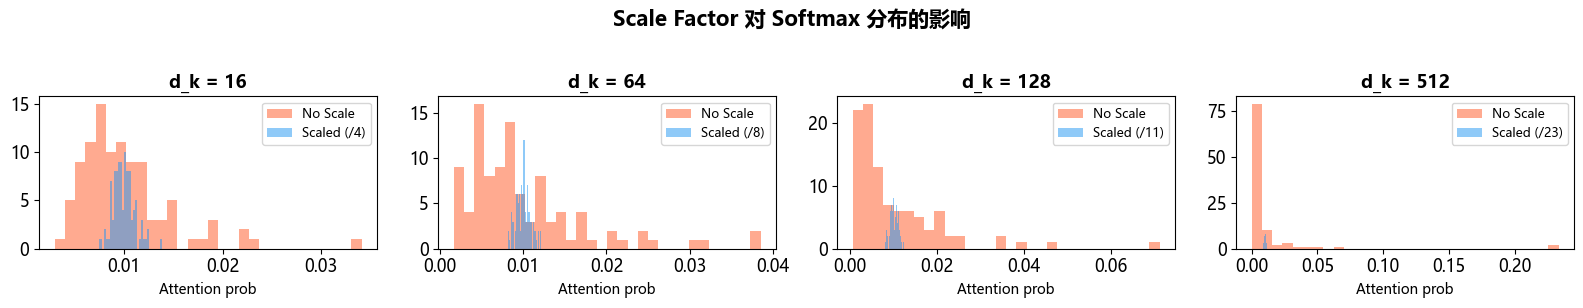

d_k=512: 不scale分布高度尖峰 -> one-hot -> 梯度消失
这就是 Scaled Dot-Product Attention 中 Scaled 的含义


In [8]:
dims = [16, 64, 128, 512]
torch.manual_seed(42)
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, d_k in zip(axes, dims):
    Q = torch.randn(1, d_k) * 0.3
    K = torch.randn(100, d_k) * 0.3
    raw = (Q @ K.T).squeeze()
    scaled = raw / (d_k ** 0.5)
    p_raw = F.softmax(raw, dim=-1)
    p_scaled = F.softmax(scaled, dim=-1)
    ax.hist(p_raw.numpy(), bins=30, alpha=0.5, label="No Scale", color="#FF5722")
    ax.hist(p_scaled.numpy(), bins=30, alpha=0.5, label=f"Scaled (/{d_k**0.5:.0f})", color="#2196F3")
    ax.set_title(f"d_k = {d_k}", fontweight="bold", fontsize=13)
    ax.legend(fontsize=9)
    ax.set_xlabel("Attention prob", fontsize=10)
plt.suptitle("Scale Factor 对 Softmax 分布的影响", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print("d_k=512: 不scale分布高度尖峰 -> one-hot -> 梯度消失")
print("这就是 Scaled Dot-Product Attention 中 Scaled 的含义")

### 3.3 QKV 投影与 GQA

Qwen3-0.6B: Q=16头, KV=8头, 每 2 个 Q 共享 1 组 KV。KV Cache 直接减半！

In [9]:
seq_len, hidden = 4, 1024
n_q_heads, n_kv_heads, head_dim = 16, 8, 128
x = torch.randn(1, seq_len, hidden)
W_Q = torch.randn(hidden, n_q_heads * head_dim)
W_K = torch.randn(hidden, n_kv_heads * head_dim)
W_V = torch.randn(hidden, n_kv_heads * head_dim)

Q = (x @ W_Q).view(1, seq_len, n_q_heads, head_dim).transpose(1, 2)
K = (x @ W_K).view(1, seq_len, n_kv_heads, head_dim).transpose(1, 2)
V = (x @ W_V).view(1, seq_len, n_kv_heads, head_dim).transpose(1, 2)

print("Qwen3-0.6B QKV 投影 (GQA):")
print(f"  Q: {tuple(Q.shape)}  -- {n_q_heads} heads")
print(f"  K: {tuple(K.shape)}   -- {n_kv_heads} heads (GQA)")
print(f"  V: {tuple(V.shape)}   -- {n_kv_heads} heads")

n_rep = n_q_heads // n_kv_heads
K_exp = K.unsqueeze(2).expand(-1, -1, n_rep, -1, -1).reshape(1, n_q_heads, seq_len, head_dim)
V_exp = V.unsqueeze(2).expand(-1, -1, n_rep, -1, -1).reshape(1, n_q_heads, seq_len, head_dim)
print(f"\nGQA repeat_kv (x{n_rep}): {tuple(K.shape)} -> {tuple(K_exp.shape)}")
print(f"  配对: Q0,Q1->KV0 | Q2,Q3->KV1 | ...")
print(f"  KV Cache 只有 {n_kv_heads/n_q_heads*100:.0f}% 的大小!")

Qwen3-0.6B QKV 投影 (GQA):
  Q: (1, 16, 4, 128)  -- 16 heads
  K: (1, 8, 4, 128)   -- 8 heads (GQA)
  V: (1, 8, 4, 128)   -- 8 heads

GQA repeat_kv (x2): (1, 8, 4, 128) -> (1, 16, 4, 128)
  配对: Q0,Q1->KV0 | Q2,Q3->KV1 | ...
  KV Cache 只有 50% 的大小!


### 3.4 RoPE——旋转编码的数学之美

RoPE 把 Q/K 的每对相邻维度视为 2D 向量，按位置旋转。
精妙之处：**Q_i·K_j 只依赖相对位置差 (i-j)**——这就是外推能力的来源。

In [10]:
def rope_rotate(x, cos, sin):
    x_rot = torch.empty_like(x)
    x_rot[..., 0::2] = x[..., 0::2] * cos - x[..., 1::2] * sin
    x_rot[..., 1::2] = x[..., 0::2] * sin + x[..., 1::2] * cos
    return x_rot

# 验证 1: 模长不变
q = torch.tensor([3.0, 4.0])
c1, s1 = math.cos(1.0), math.sin(1.0)
q_rot = rope_rotate(q, torch.tensor([c1]), torch.tensor([s1]))
print(f"验证1 模长不变: |q|={q.norm():.4f}, |q_rot|={q_rot.norm():.4f}")
print(f"  旋转角={(math.degrees(math.acos((q@q_rot)/(q.norm()*q_rot.norm())))):.1f}度 = 1.0 rad")

# 验证 2: 相对位置 R_i^T R_j = R_{j-i}
ca,sa=math.cos(0.5),math.sin(0.5); cb,sb=math.cos(0.3),math.sin(0.3)
R1=torch.tensor([[ca,-sa],[sa,ca]]); R2=torch.tensor([[cb,-sb],[sb,cb]])
R_diff=R1.T@R2; cd,sd=math.cos(0.3-0.5),math.sin(0.3-0.5)
R_exp=torch.tensor([[cd,-sd],[sd,cd]])
print(f"\n验证2 相对位置: max err={(R_diff-R_exp).abs().max():.2e}")
print(f"  R_i^T*R_j = R_{{j-i}}  得证!")

# 验证 3: Qwen3 128维频率
print(f"\n验证3 Qwen3-0.6B theta=1e6, 128维频率:")
for d in [0, 32, 64, 126]:
    period = 2*math.pi/(1.0/(1000000.0**(d/128)))
    print(f"  dim {d:>3}: period={period:.0f} tokens")
print("低维旋转快(tok级) 高维旋转慢(句级)")

验证1 模长不变: |q|=5.0000, |q_rot|=5.0000
  旋转角=57.3度 = 1.0 rad

验证2 相对位置: max err=1.49e-08
  R_i^T*R_j = R_{j-i}  得证!

验证3 Qwen3-0.6B theta=1e6, 128维频率:
  dim   0: period=6 tokens
  dim  32: period=199 tokens
  dim  64: period=6283 tokens
  dim 126: period=5063256 tokens
低维旋转快(tok级) 高维旋转慢(句级)


---
## 4. LSTM 与 GRU——循环神经网络的梯度博弈

### 4.1 RNN 梯度消失——数学本质

反向传播时梯度要穿过时间：∂L/∂h₀ = ∂L/∂h_T × Π W·tanh'。
每步乘子<1 时，连乘 T 次后梯度指数衰减。下面模拟 100 步传播。

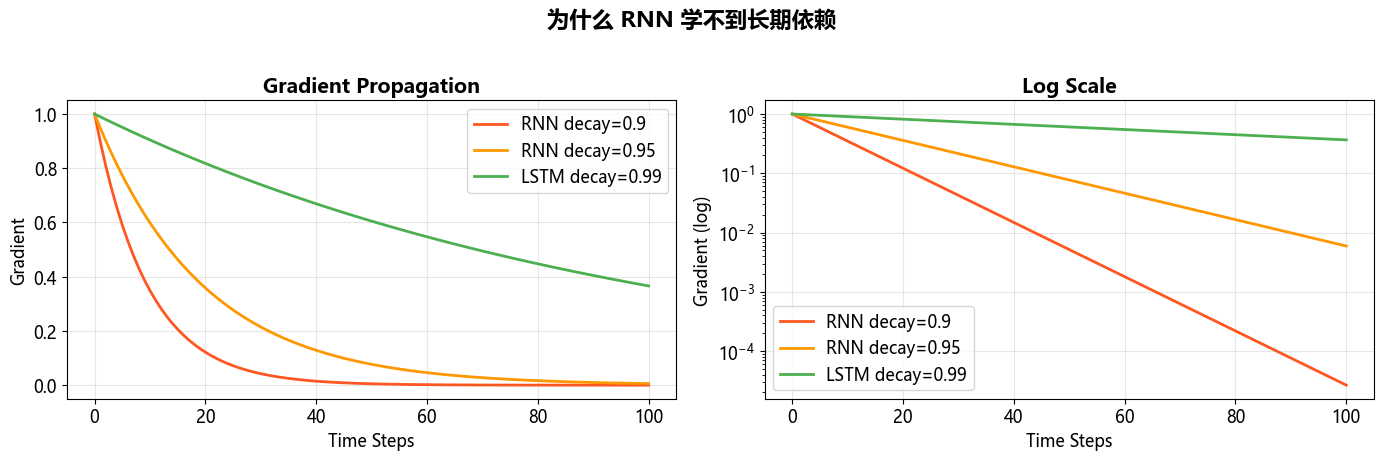

T=100 梯度衰减:
  RNN decay=0.9:  0.9^100  = 2.66e-05
  RNN decay=0.95: 0.95^100 = 0.0059
  LSTM decay=0.99: 0.99^100 = 0.3660
  关键: LSTM 用逐元素乘替代矩阵乘!


In [11]:
T = 100
steps = np.arange(T + 1)
rnn_09 = 0.9 ** steps
rnn_095 = 0.95 ** steps
lstm_099 = 0.99 ** steps

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.plot(steps, rnn_09, lw=2, color="#FF5722", label="RNN decay=0.9")
ax1.plot(steps, rnn_095, lw=2, color="#FF9800", label="RNN decay=0.95")
ax1.plot(steps, lstm_099, lw=2, color="#4CAF50", label="LSTM decay=0.99")
ax1.set_xlabel("Time Steps"); ax1.set_ylabel("Gradient")
ax1.set_title("Gradient Propagation", fontweight="bold")
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.semilogy(steps, rnn_09, lw=2, color="#FF5722", label="RNN decay=0.9")
ax2.semilogy(steps, rnn_095, lw=2, color="#FF9800", label="RNN decay=0.95")
ax2.semilogy(steps, lstm_099, lw=2, color="#4CAF50", label="LSTM decay=0.99")
ax2.set_xlabel("Time Steps"); ax2.set_ylabel("Gradient (log)")
ax2.set_title("Log Scale", fontweight="bold")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.suptitle("为什么 RNN 学不到长期依赖", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print(f"T=100 梯度衰减:")
print(f"  RNN decay=0.9:  0.9^100  = {0.9**100:.2e}")
print(f"  RNN decay=0.95: 0.95^100 = {0.95**100:.4f}")
print(f"  LSTM decay=0.99: 0.99^100 = {0.99**100:.4f}")
print(f"  关键: LSTM 用逐元素乘替代矩阵乘!")

### 4.2 LSTM——梯度高速公路

c_t = f_t ⊙ c_{t-1} + i_t ⊙ c̃_t。∂c_t/∂c_{t-1} = f_t——逐元素乘，没有矩阵乘法！
f_t≈1 时梯度几乎无损穿过时间。下面手写 LSTM 四个门控。

In [12]:
def lstm_step(x_t, h_prev, c_prev, W_ih, W_hh, b_ih, b_hh):
    hidden = h_prev.shape[-1]
    gates = x_t @ W_ih.T + b_ih + h_prev @ W_hh.T + b_hh
    f = torch.sigmoid(gates[:, :hidden])
    i = torch.sigmoid(gates[:, hidden:2*hidden])
    g = torch.tanh(gates[:, 2*hidden:3*hidden])
    o = torch.sigmoid(gates[:, 3*hidden:])
    c_t = f * c_prev + i * g
    h_t = o * torch.tanh(c_t)
    return h_t, c_t

hidden, input_dim = 64, 32
torch.manual_seed(42)
W_ih = torch.randn(4 * hidden, input_dim) * 0.1
W_hh = torch.randn(4 * hidden, hidden) * 0.1
b_ih = torch.zeros(4 * hidden)
b_hh = torch.zeros(4 * hidden)
h, c = torch.zeros(1, hidden), torch.zeros(1, hidden)
xs = torch.randn(5, 1, input_dim)
print("LSTM 序列前向 (5步):")
for t in range(5):
    h, c = lstm_step(xs[t], h, c, W_ih, W_hh, b_ih, b_hh)
    print(f"  t={t}: h mean={h.mean():.4f}")
print(f"\n关键: d(c_t)/d(c_{{t-1}}) = f_t (逐元素乘, 无矩阵乘!)")
print(f"对比 RNN: d(h_t)/d(h_{{t-1}}) approx W (矩阵乘, 易衰减)")

LSTM 序列前向 (5步):
  t=0: h mean=0.0195
  t=1: h mean=0.0179
  t=2: h mean=0.0158
  t=3: h mean=0.0099
  t=4: h mean=0.0112

关键: d(c_t)/d(c_{t-1}) = f_t (逐元素乘, 无矩阵乘!)
对比 RNN: d(h_t)/d(h_{t-1}) approx W (矩阵乘, 易衰减)


### 4.3 GRU vs LSTM——简化的智慧

GRU 合并遗忘门+输入门→更新门 z，保留重置门 r。参数少 ~25%，多数任务效果相当。

In [13]:
def gru_step(x_t, h_prev, W_ih, W_hh, b_ih, b_hh):
    hidden = h_prev.shape[-1]
    gates = x_t @ W_ih.T + b_ih + h_prev @ W_hh.T + b_hh
    r = torch.sigmoid(gates[:, :hidden])
    z = torch.sigmoid(gates[:, hidden:2*hidden])
    n = torch.tanh(x_t @ W_ih[2*hidden:3*hidden].T + b_ih[2*hidden:3*hidden]
        + r * (h_prev @ W_hh[2*hidden:3*hidden].T + b_hh[2*hidden:3*hidden]))
    h_t = (1 - z) * h_prev + z * n
    return h_t

hd, inp = 128, 64
lstm_p = 4 * hd * (hd + inp)
gru_p  = 3 * hd * (hd + inp)
print(f"参数量 (hidden={hd}, input={inp}):")
print(f"  LSTM: {lstm_p:,} = 4 x {hd} x ({hd}+{inp})")
print(f"  GRU:  {gru_p:,} = 3 x {hd} x ({hd}+{inp})")
print(f"  GRU 省 {(1-gru_p/lstm_p)*100:.0f}%")

torch.manual_seed(42)
W_ih_g = torch.randn(3 * hd, inp) * 0.1
W_hh_g = torch.randn(3 * hd, hd) * 0.1
b_ih_g = torch.zeros(3 * hd)
b_hh_g = torch.zeros(3 * hd)
h = torch.zeros(1, hd)
for t in range(5):
    h = gru_step(torch.randn(1, inp), h, W_ih_g, W_hh_g, b_ih_g, b_hh_g)
print(f"GRU 验证: output shape={tuple(h.shape)}, mean={h.mean():.4f}")

参数量 (hidden=128, input=64):
  LSTM: 98,304 = 4 x 128 x (128+64)
  GRU:  73,728 = 3 x 128 x (128+64)
  GRU 省 25%
GRU 验证: output shape=(1, 128), mean=-0.0309


---
## 5. 嵌入——离散世界的连续化翻译

### 5.1 Embedding 的本质——查表

一个离散整数→1024维连续向量。语义相近的词在空间中距离近。
Qwen3-0.6B 的 Embedding 有 1.56 亿参数，占总参 26%！

In [14]:
vocab_size, emb_dim = 1000, 64
torch.manual_seed(42)
embed = nn.Embedding(vocab_size, emb_dim)

word_ids = {"猫":42, "狗":43, "老虎":44, "汽车":128, "火车":129, "飞机":130, "苹果":256, "香蕉":257}
vecs = {w: embed(torch.tensor(tid)).detach() for w, tid in word_ids.items()}

print("词向量余弦相似度矩阵:")
words = list(word_ids.keys())
print("      " + " ".join(f"{w:>6}" for w in words))
for w1 in words:
    row = f"{w1:>6} "
    for w2 in words:
        sim = F.cosine_similarity(vecs[w1].unsqueeze(0), vecs[w2].unsqueeze(0)).item()
        row += f"{sim:>6.2f} "
    print(row)

real_vocab, real_dim = 151936, 1024
params = real_vocab * real_dim
print(f"\nQwen3-0.6B: {real_vocab}x{real_dim} = {params/1e8:.2f}亿参数 = {params/6e8*100:.0f}%总参")

词向量余弦相似度矩阵:
           猫      狗     老虎     汽车     火车     飞机     苹果     香蕉
     猫   1.00   0.14  -0.07  -0.09   0.07  -0.12  -0.11   0.08 
     狗   0.14   1.00   0.10   0.16   0.02  -0.06  -0.10   0.22 
    老虎  -0.07   0.10   1.00   0.17  -0.03  -0.11   0.22   0.09 
    汽车  -0.09   0.16   0.17   1.00   0.02  -0.16   0.25   0.03 
    火车   0.07   0.02  -0.03   0.02   1.00  -0.08   0.21  -0.07 
    飞机  -0.12  -0.06  -0.11  -0.16  -0.08   1.00   0.05  -0.02 
    苹果  -0.11  -0.10   0.22   0.25   0.21   0.05   1.00  -0.07 
    香蕉   0.08   0.22   0.09   0.03  -0.07  -0.02  -0.07   1.00 

Qwen3-0.6B: 151936x1024 = 1.56亿参数 = 26%总参


### 5.2 三种位置编码全家福

可学习PE(BERT): 简单但无法外推。正弦PE(原版Transformer): 可外推但绝对位置。
RoPE(Qwen/LLaMA): 编码相对位置，支持长上下文——现代 LLM 标配。

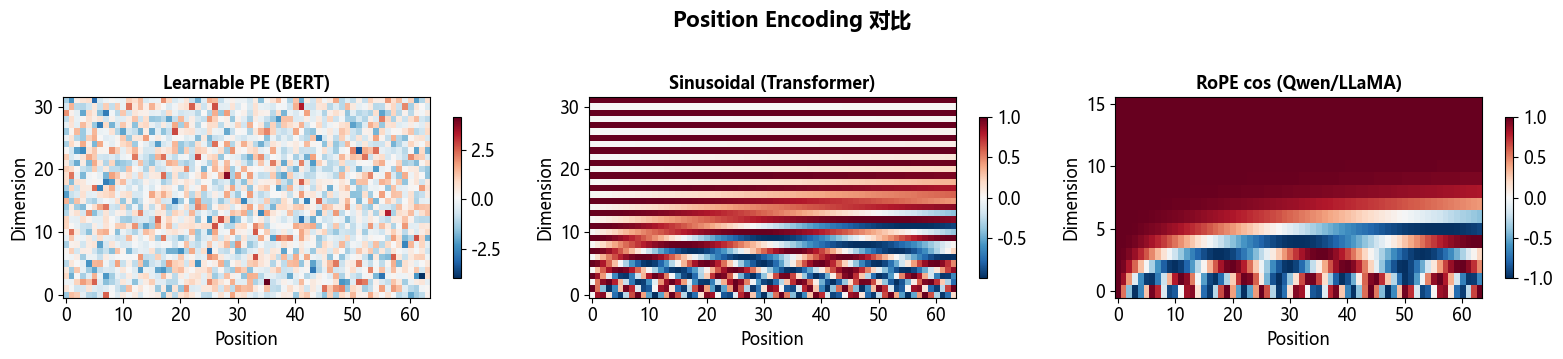

可学习PE: 简单, 无法外推
正弦PE: 可外推, 无参数, 但绝对位置
RoPE: 编码相对位置, 支持长上下文, 现代LLM标配


In [15]:
seq_len, d_model = 64, 32
position = np.arange(seq_len)[:, np.newaxis]
div_term = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
pe_sin = np.zeros((seq_len, d_model))
pe_sin[:, 0::2] = np.sin(position * div_term)
pe_sin[:, 1::2] = np.cos(position * div_term)

learnable_pe = nn.Embedding(seq_len, d_model)
pe_learn = learnable_pe(torch.arange(seq_len)).detach().numpy()

freqs = 1.0 / (10000.0 ** (torch.arange(0, d_model, 2).float() / d_model))
cos_rope = torch.cos(torch.arange(seq_len).float().unsqueeze(1) * freqs.unsqueeze(0))
pe_rope = cos_rope.numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))
titles = ["Learnable PE (BERT)", "Sinusoidal (Transformer)", "RoPE cos (Qwen/LLaMA)"]
for ax, title, d in zip(axes, titles, [pe_learn, pe_sin, pe_rope]):
    im = ax.imshow(d.T, aspect="auto", cmap="RdBu_r", origin="lower")
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_xlabel("Position"); ax.set_ylabel("Dimension")
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("Position Encoding 对比", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print("可学习PE: 简单, 无法外推")
print("正弦PE: 可外推, 无参数, 但绝对位置")
print("RoPE: 编码相对位置, 支持长上下文, 现代LLM标配")

---
## Summary

| Concept | Experiment | Key Insight |
|---------|-----------|-------------|
| Conv 6 Params | kernel/stride/pad/dil/groups/bias | 两个 3x3 = 一个 5x5 感受野 |
| im2col | 5x5 -> 9x9 matrix demo | 膨胀 k^2 倍内存换 GEMM 算力 |
| Winograd | F(2x2,3x3) transform | 36->16 次乘法, 用加法换 |
| Receptive Field | 3-layer VGG | RF=7, 参数 27 < 49 |
| NCHW vs NHWC | Memory layout | 选对布局 = 2x 速度提升 |
| SDPA 5 Steps | QKT->scale->mask->softmax->V | 每步有明确数学含义 |
| Scale Factor | Distribution histogram | d_k 大时 scale 防 one-hot |
| GQA | repeat_kv (8->16 heads) | KV Cache 减半 |
| RoPE | Rotation + relative proof | 相对位置 = 外推能力 |
| RNN Gradient | 0.9^100 ≈ 2.7e-5 | 指数衰减->长期依赖丢失 |
| LSTM Highway | f_t * c_{t-1} (element-wise) | 无矩阵乘 = 梯度高速路 |
| GRU vs LSTM | 3 gates vs 4 gates | 省 25% 参数, 效果相当 |
| Embedding | Cosine similarity | 语义向量空间中靠近 |
| Position Encoding | 3 types viz | RoPE = 现代 LLM 标配 |